In [197]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os
from shapely.ops import nearest_points
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString
from shapely.geometry import box


TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"
MILES_TO_METERS = 1609.344

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

In [198]:
EFFECTIVE_SPEEDS_MPH = {
    "I": 80,
    "U": 60,
    "S": 40,
}

In [233]:
Centerline_Interstates = gpd.read_file("./maps/raw/IL_Interstate_Centerlines.geojson").to_crs(TARGET_CRS)
Centerline_USHighways = gpd.read_file("./maps/raw/IL_USHighways_Centerlines.geojson").to_crs(TARGET_CRS)
Centerline_StateHighways = gpd.read_file("./maps/raw/IL_StateHighways_Centerlines.geojson").to_crs(TARGET_CRS)

ILPlaces2022WithChicagoCommunity_AndCensus = gpd.read_file("./maps/raw/IL/ILPlaces2025_WithChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

# Supplemental
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)

# View areas
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ILNorthern = gpd.read_file("./maps/raw/IL/IL_Northern.geojson").to_crs(TARGET_CRS)
IL_IATriCityArea = gpd.read_file("./maps/raw/IL/IL_IATriCityArea.geojson").to_crs(TARGET_CRS)

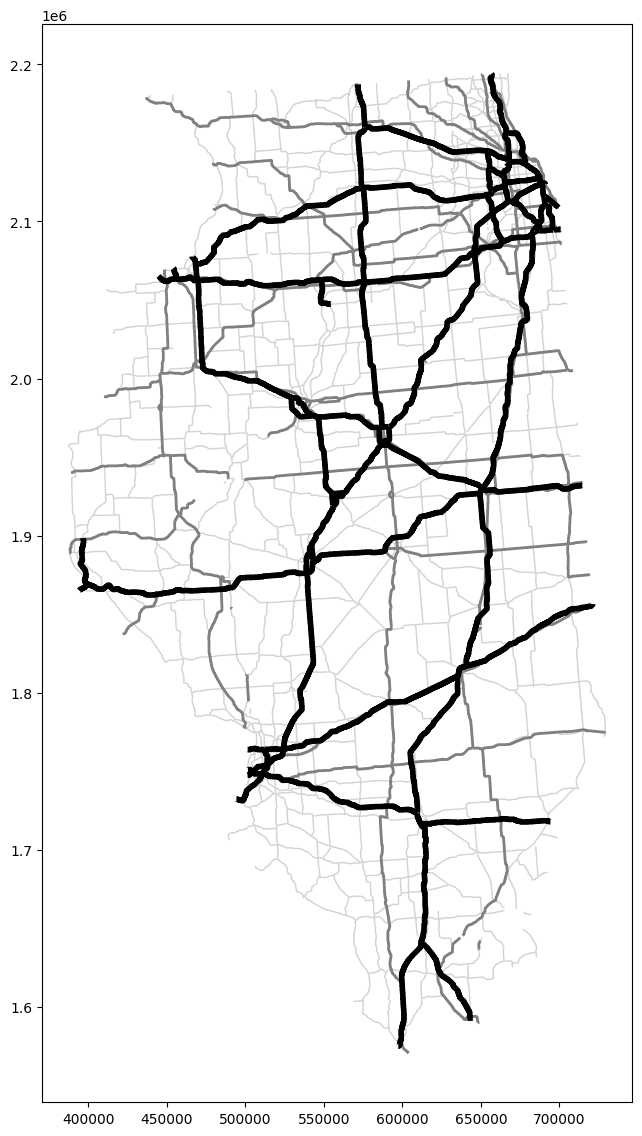

In [200]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(14, 14)
)

# Original multilane roads
Centerline_Interstates.plot(
    ax=ax,
    color="black",
    linewidth=4,
    zorder=3
)

# Raster-derived centerlines
Centerline_USHighways.plot(
    ax=ax,
    color="grey",
    linewidth=2,
    zorder=2
)

Centerline_StateHighways.plot(
    ax=ax,
    color="lightgrey",
    linewidth=1,
    zorder=1
)

plt.show()

In [236]:
Centerline_Interstates = Centerline_Interstates.copy()
Centerline_USHighways = Centerline_USHighways.copy()
Centerline_StateHighways = Centerline_StateHighways.copy()

Centerline_Interstates["origin"] = "I"
Centerline_USHighways["origin"] = "U"
Centerline_StateHighways["origin"] = "S"

roads = gpd.GeoDataFrame(
    pd.concat(
        [
            Centerline_Interstates,
            Centerline_USHighways,
            Centerline_StateHighways,
        ],
        ignore_index=True,
    ),
    geometry="geometry",
    crs=TARGET_CRS,
)

In [237]:
G = nx.Graph()

for edge_id, row in roads.iterrows():

    geom = row.geometry

    # Atomic segments should be LineStrings
    if geom is None or geom.is_empty:
        continue

    if geom.geom_type != "LineString":
        continue

    coords = list(geom.coords)

    # Endpoints become graph nodes
    u = tuple(coords[0])
    v = tuple(coords[-1])

    # Add nodes
    G.add_node(
        u,
        x=u[0],
        y=u[1],
    )

    G.add_node(
        v,
        x=v[0],
        y=v[1],
    )

    # Add edge and preserve all original attributes
    edge_attributes = row.drop(
        labels="geometry"
    ).to_dict()

    edge_attributes["geometry"] = geom
    edge_attributes["edge_id"] = edge_id
    edge_attributes['origin'] = row['origin']

    G.add_edge(
        u,
        v,
        **edge_attributes,
    )

In [203]:
import networkx as nx

# Get all connected components
components = list(nx.connected_components(G))

# Sort largest → smallest
components = sorted(
    components,
    key=len,
    reverse=True,
)

print(f"Number of subnetworks: {len(components)}")

for i, nodes in enumerate(components[:10], start=1):
    print(
        f"Subgraph {i}: "
        f"{len(nodes):,} nodes"
    )

Number of subnetworks: 23
Subgraph 1: 2,554 nodes
Subgraph 2: 400 nodes
Subgraph 3: 282 nodes
Subgraph 4: 7 nodes
Subgraph 5: 4 nodes
Subgraph 6: 2 nodes
Subgraph 7: 2 nodes
Subgraph 8: 2 nodes
Subgraph 9: 2 nodes
Subgraph 10: 2 nodes


In [204]:
subgraphs = [
    G.subgraph(nodes).copy()
    for nodes in components
]

In [205]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert all graph edges into one GeoDataFrame
edge_records = []

for component_id, SG in enumerate(subgraphs, start=1):

    for u, v, data in SG.edges(data=True):

        geom = data.get("geometry")

        if geom is None or geom.is_empty:
            continue

        edge_records.append({
            "component_id": component_id,
            "origin": data.get("origin"),
            "geometry": geom,
        })

subgraph_edges = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs=roads.crs,
)

subgraph_edges.head()

,component_id,origin,geometry
0,1,S,"LINESTRING (391202.695 1889374.96, 391041.761 ..."
1,1,S,"LINESTRING (391202.695 1889374.96, 391363.63 1..."
2,1,S,"LINESTRING (391202.695 1889374.96, 391202.695 ..."
3,1,S,"LINESTRING (391041.761 1889374.96, 391202.695 ..."
4,1,S,"LINESTRING (391041.761 1889374.96, 390880.827 ..."


In [206]:
import geopandas as gpd
from shapely.geometry import Point, MultiPoint

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

# TARGET_CRS must use meters, such as EPSG:5070
ONE_MILE = 5 * 1609.344


# --------------------------------------------------
# A. FIND INTERSTATE ↔ U.S. HIGHWAY CANDIDATES
# --------------------------------------------------

interstates = Centerline_Interstates[
    ["geometry"]
].copy()

us_highways = Centerline_USHighways[
    ["geometry"]
].copy()

# Preserve IDs from the original GeoDataFrames
interstates["interstate_id"] = interstates.index

us_highways["us_highway_id"] = us_highways.index

# Find Interstate/U.S. Highway line pairs that intersect
pairs = gpd.sjoin(
    interstates,
    us_highways[
        [
            "us_highway_id",
            "geometry",
        ]
    ],
    how="inner",
    predicate="intersects",
)

print(
    f"Intersecting line pairs: "
    f"{len(pairs):,}"
)


# --------------------------------------------------
# B. GET INTERSECTION POINTS
#    KEEP ONLY ONE POINT PER MILE PER LINE PAIR
# --------------------------------------------------

# U.S. highway geometry lookup
us_geometry = (
    us_highways
    .set_index("us_highway_id")
    .geometry
)

intersection_records = []

for _, row in pairs.iterrows():

    interstate_line = row.geometry

    us_line = us_geometry.loc[
        row["us_highway_id"]
    ]

    # Exact intersection geometry
    intersection = (
        interstate_line.intersection(
            us_line
        )
    )

    if (
        intersection is None
        or intersection.is_empty
    ):
        continue

    # Convert Point/MultiPoint to a list of points
    if intersection.geom_type == "Point":

        points = [
            intersection
        ]

    elif intersection.geom_type == "MultiPoint":

        points = list(
            intersection.geoms
        )

    else:

        # Ignore LineString, MultiLineString,
        # GeometryCollection, etc.
        continue

    # Sort points by their position along
    # the Interstate line
    points = sorted(
        points,
        key=interstate_line.project,
    )

    kept_points = []

    for point in points:

        # Keep the first point
        if not kept_points:

            kept_points.append(
                point
            )

            continue

        # Distance along the Interstate line
        # from the most recently retained point
        distance_along_line = (
            interstate_line.project(point)
            -
            interstate_line.project(
                kept_points[-1]
            )
        )

        # Keep only if at least one mile away
        if (
            distance_along_line
            >= ONE_MILE
        ):

            kept_points.append(
                point
            )

    # Save retained points
    for point in kept_points:

        intersection_records.append(
            {
                "interstate_id":
                    row["interstate_id"],

                "us_highway_id":
                    row["us_highway_id"],

                "geometry":
                    point,
            }
        )


# --------------------------------------------------
# C. SIMPLIFY POINT + MULTIPOINT RESULTS
#    INTO ONE GEODATAFRAME
# --------------------------------------------------

interstate_us_intersections = (
    gpd.GeoDataFrame(
        intersection_records,
        geometry="geometry",
        crs=TARGET_CRS,
    )
    .drop_duplicates(
        subset="geometry"
    )
    .reset_index(
        drop=True
    )
)

print(
    f"Final unique intersection points: "
    f"{len(interstate_us_intersections):,}"
)

interstate_us_intersections.head()

Intersecting line pairs: 188
Final unique intersection points: 148


,interstate_id,us_highway_id,geometry
0,1,0,POINT (396836.681 1897695.307)
1,9,83,POINT (484744.456 1865830.295)
2,9,84,POINT (484583.521 1865830.295)
3,9,90,POINT (489894.357 1866795.902)
4,9,92,POINT (490055.291 1866795.902)


In [207]:
def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

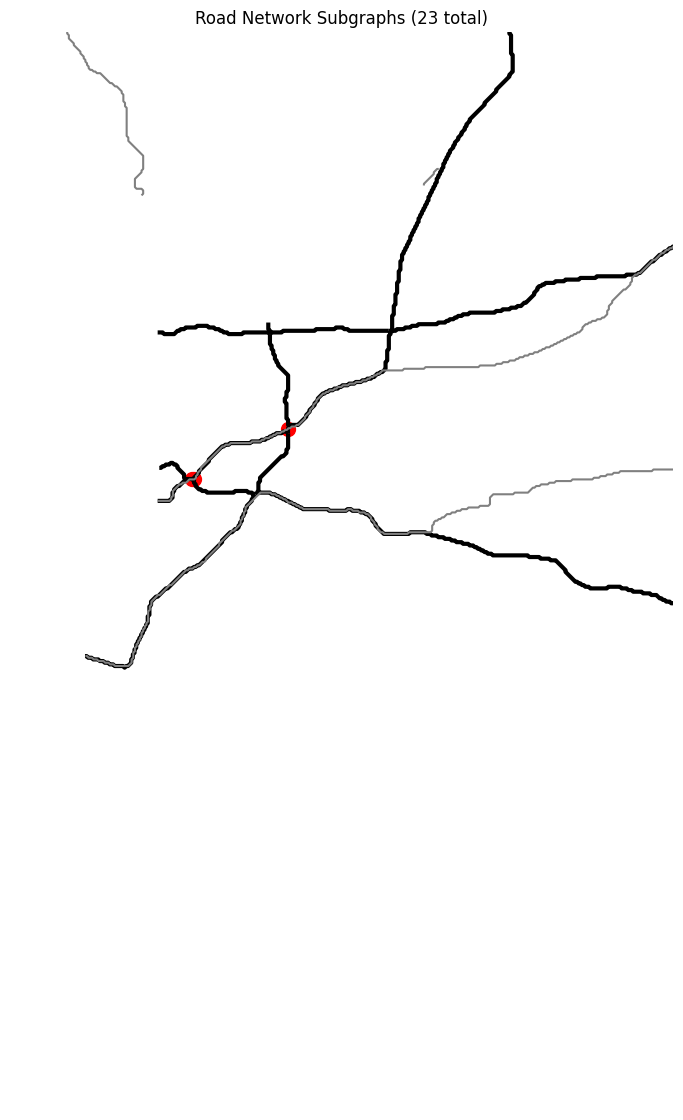

In [208]:
import matplotlib.pyplot as plt

ORIGIN_WIDTHS = {
    "I": 2.5,
    "U": 1.5,
    "S": 0.8,
}

fig, ax = plt.subplots(figsize=(14, 14))

Centerline_Interstates.plot(
    ax=ax,
    edgecolor="black",
    linewidth=3,
    legend=False,
)

Centerline_USHighways.plot(
    ax=ax,
    edgecolor="grey",
    linewidth=1.5,
    legend=False,
)

interstate_us_intersections.plot(
    ax=ax,
    markersize=100,
    color="red"
)

ax.set_title(
    f"Road Network Subgraphs ({len(subgraphs):,} total)"
)


ZoomToTheExtentOf(ax, ILSTLArea)
ax.set_axis_off()

plt.show()

In [209]:
import pandas as pd
import geopandas as gpd

from shapely.geometry import (
    Point,
    MultiPoint,
)
from shapely.ops import split


# --------------------------------------------------
# 1. COPY THE ORIGINAL ATOMIC ROAD DATA
# --------------------------------------------------

interstates = Centerline_Interstates.copy()
us_highways = Centerline_USHighways.copy()

# Preserve original row IDs
interstates["source_id"] = interstates.index
us_highways["source_id"] = us_highways.index

# Preserve road origin
interstates["origin"] = "I"
us_highways["origin"] = "U"


# --------------------------------------------------
# 2. CREATE INTERSECTION-POINT LOOKUPS
# --------------------------------------------------

# Points that split each Interstate line
interstate_split_points = (
    interstate_us_intersections
    .groupby("interstate_id")["geometry"]
    .apply(list)
    .to_dict()
)

# Points that split each U.S. Highway line
us_highway_split_points = (
    interstate_us_intersections
    .groupby("us_highway_id")["geometry"]
    .apply(list)
    .to_dict()
)


# --------------------------------------------------
# 3. FUNCTION TO SPLIT ONE LINE
# --------------------------------------------------

def split_line_at_points(
    line,
    points,
):
    """
    Split a LineString using a list of Point geometries.

    Returns a list of LineStrings.
    """

    # No intersection points:
    # keep the original atomic line
    if not points:
        return [line]

    # Remove duplicate points
    unique_points = []

    seen = set()

    for point in points:

        point_key = (
            round(point.x, 8),
            round(point.y, 8),
        )

        if point_key not in seen:

            seen.add(point_key)

            unique_points.append(point)

    # Keep only points that lie on the line
    valid_points = [
        point
        for point in unique_points
        if line.distance(point) < 1e-8
    ]

    # No valid split points
    if not valid_points:
        return [line]

    # Split using all points simultaneously
    try:

        result = split(
            line,
            MultiPoint(valid_points),
        )

        return [
            geom
            for geom in result.geoms
            if (
                geom.geom_type == "LineString"
                and not geom.is_empty
                and geom.length > 0
            )
        ]

    except Exception:

        # Preserve the original line
        # if splitting fails
        return [line]


# --------------------------------------------------
# 4. SPLIT INTERSTATE LINES
# --------------------------------------------------

interstate_records = []

for _, row in interstates.iterrows():

    line = row.geometry

    if (
        line is None
        or line.is_empty
    ):
        continue

    points = (
        interstate_split_points
        .get(
            row["source_id"],
            [],
        )
    )

    segments = split_line_at_points(
        line,
        points,
    )

    # Preserve all original attributes
    attributes = (
        row
        .drop(
            labels="geometry"
        )
        .to_dict()
    )

    for segment_number, segment in enumerate(
        segments,
        start=1,
    ):

        interstate_records.append(
            {
                **attributes,

                "segment_number":
                    segment_number,

                "geometry":
                    segment,
            }
        )


# --------------------------------------------------
# 5. SPLIT U.S. HIGHWAY LINES
# --------------------------------------------------

us_highway_records = []

for _, row in us_highways.iterrows():

    line = row.geometry

    if (
        line is None
        or line.is_empty
    ):
        continue

    points = (
        us_highway_split_points
        .get(
            row["source_id"],
            [],
        )
    )

    segments = split_line_at_points(
        line,
        points,
    )

    # Preserve all original attributes
    attributes = (
        row
        .drop(
            labels="geometry"
        )
        .to_dict()
    )

    for segment_number, segment in enumerate(
        segments,
        start=1,
    ):

        us_highway_records.append(
            {
                **attributes,

                "segment_number":
                    segment_number,

                "geometry":
                    segment,
            }
        )


# --------------------------------------------------
# 6. CREATE SPLIT GEODATAFRAMES
# --------------------------------------------------

split_interstates = gpd.GeoDataFrame(
    interstate_records,
    geometry="geometry",
    crs=TARGET_CRS,
)

split_us_highways = gpd.GeoDataFrame(
    us_highway_records,
    geometry="geometry",
    crs=TARGET_CRS,
)


# --------------------------------------------------
# 7. MERGE INTO ONE ATOMIC ROAD GDF
# --------------------------------------------------

atomic_interstate_us_roads = gpd.GeoDataFrame(
    pd.concat(
        [
            split_interstates,
            split_us_highways,
        ],
        ignore_index=True,
        sort=False,
    ),
    geometry="geometry",
    crs=TARGET_CRS,
)


# --------------------------------------------------
# 8. ADD A UNIQUE ATOMIC SEGMENT ID
# --------------------------------------------------

atomic_interstate_us_roads.insert(
    0,
    "atomic_id",
    range(
        len(
            atomic_interstate_us_roads
        )
    ),
)


# --------------------------------------------------
# 9. RESULTS
# --------------------------------------------------

print(
    "Original Interstate lines:",
    len(interstates),
)

print(
    "Split Interstate segments:",
    len(split_interstates),
)

print()

print(
    "Original U.S. Highway lines:",
    len(us_highways),
)

print(
    "Split U.S. Highway segments:",
    len(split_us_highways),
)

print()

print(
    "Merged atomic segments:",
    len(atomic_interstate_us_roads),
)

atomic_interstate_us_roads.head()

Original Interstate lines: 437
Split Interstate segments: 546

Original U.S. Highway lines: 621
Split U.S. Highway segments: 727

Merged atomic segments: 1273


,atomic_id,length_miles,origin,source_id,segment_number,geometry
0,0,4.3456,I,0,1,"LINESTRING (394261.73 1865025.623, 394422.665 ..."
1,1,20.5024,I,1,1,"LINESTRING (396675.746 1898339.044, 396675.746..."
2,2,20.5024,I,1,2,"LINESTRING (396836.681 1897695.307, 396836.681..."
3,3,0.1414,I,2,1,"LINESTRING (399089.762 1869209.918, 398928.828..."
4,4,0.1000,I,3,1,"LINESTRING (398928.828 1869209.918, 398928.828..."


In [220]:
atomic_interstate_us_roads["speed_mph"] = (
    atomic_interstate_us_roads["origin"]
    .map({
        "I": 80,
        "U": 60,
        "S": 40,
    })
)

atomic_interstate_us_roads["length_miles"] = (
    atomic_interstate_us_roads.geometry.length / 1609.344
)

atomic_interstate_us_roads["travel_time_hours"] = (
    atomic_interstate_us_roads["length_miles"]
    / atomic_interstate_us_roads["speed_mph"]
)

In [239]:
import networkx as nx
from shapely.geometry import LineString, MultiLineString

# Undirected graph
G = nx.Graph()

for road_id, road in atomic_interstate_us_roads.iterrows():

    geom = road.geometry

    # Skip missing or empty geometries
    if geom is None or geom.is_empty:
        continue

    # Atomic roads should normally be LineStrings
    if isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
    else:
        parts = [geom]

    for part_num, line in enumerate(parts):

        # Get the two endpoint coordinates
        start = tuple(line.coords[0])
        end = tuple(line.coords[-1])

        # Add the edge with miles as the routing weight
        G.add_edge(
            start,
            end,
            road_id=road_id,
            part_num=part_num,
            origin=road['origin'],
            length_miles=road["length_miles"],
            travel_time_hours=road['travel_time_hours'],
            geometry=line,
        )

print(
    f"Graph has {G.number_of_nodes():,} nodes "
    f"and {G.number_of_edges():,} edges"
)

Graph has 826 nodes and 1,259 edges


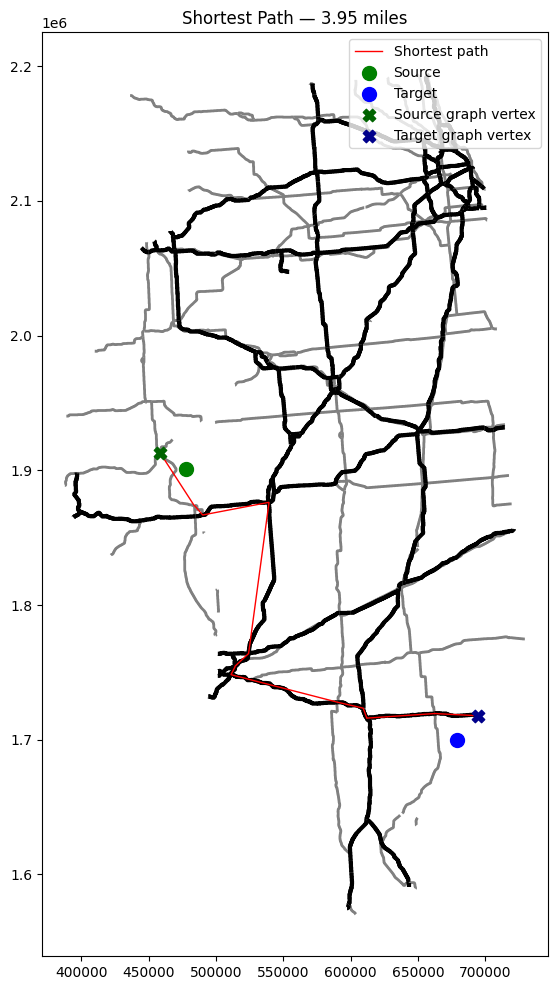

In [250]:
# Find closest graph node to source

weight = "travel_time_hours"


source_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'Beardstown')
)].iloc[0]


target_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'Carmi')
)].iloc[0]

source_node = get_closest_vertex(source_point.geometry.representative_point(), G)
target_node = get_closest_vertex(target_point.geometry.representative_point(), G)

# Run shortest path using edge mileage
route_nodes = nx.shortest_path(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
)

route_miles = nx.shortest_path_length(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
    )


import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# Convert the ordered route nodes into a line
route_line = LineString(route_nodes)

# Plot
fig, ax = plt.subplots(
    figsize=(12, 12)
)

# Plot all atomic roads
atomic_interstate_us_roads[
    (atomic_interstate_us_roads['origin'] == 'I')
].plot(
    ax=ax,
    color="black",
    linewidth=3,
     zorder=3
)

atomic_interstate_us_roads[
    (atomic_interstate_us_roads['origin'] == 'U')
].plot(
    ax=ax,
    color="grey",
    linewidth=2,
    zorder=2
)


# Plot the shortest path
ax.plot(
    *route_line.xy,
    color="red",
    linewidth=1,
    label="Shortest path",
     zorder=4
)

# Plot the original source and target representative points
ax.scatter(
    source_point.geometry.representative_point().x,
    source_point.geometry.representative_point().y,
    color="green",
    s=100,
    marker="o",
    label="Source",
    zorder=5,
)

ax.scatter(
    target_point.geometry.representative_point().x,
    target_point.geometry.representative_point().y,
    color="blue",
    s=100,
    marker="o",
    label="Target",
    zorder=5,
)

# Plot the graph vertices used for routing
ax.scatter(
    source_node[0],
    source_node[1],
    color="darkgreen",
    s=80,
    marker="X",
    label="Source graph vertex",
    zorder=6,
)

ax.scatter(
    target_node[0],
    target_node[1],
    color="darkblue",
    s=80,
    marker="X",
    label="Target graph vertex",
    zorder=6,
)

ax.legend()

ax.set_title(
    f"Shortest Path — {route_miles:.2f} miles"
)

plt.show()

#### Merge Interstates-US Highways into State Highways

In [251]:
import pandas as pd
import geopandas as gpd

from shapely.geometry import (
    Point,
    MultiPoint,
)
from shapely.ops import split


# --------------------------------------------------
# 1. COPY THE ORIGINAL ATOMIC ROAD DATA
# --------------------------------------------------

interstates = atomic_interstate_us_roads.copy()
us_highways = Centerline_StateHighways.copy()

# Preserve original row IDs
interstates["source_id"] = interstates.index
us_highways["source_id"] = us_highways.index

# Preserve road origin
# interstates["origin"] = "I"
us_highways["origin"] = "S"


# --------------------------------------------------
# 2. CREATE INTERSECTION-POINT LOOKUPS
# --------------------------------------------------

# Points that split each Interstate line
interstate_split_points = (
    interstate_us_intersections
    .groupby("interstate_id")["geometry"]
    .apply(list)
    .to_dict()
)

# Points that split each U.S. Highway line
us_highway_split_points = (
    interstate_us_intersections
    .groupby("us_highway_id")["geometry"]
    .apply(list)
    .to_dict()
)


# --------------------------------------------------
# 3. FUNCTION TO SPLIT ONE LINE
# --------------------------------------------------

def split_line_at_points(
    line,
    points,
):
    """
    Split a LineString using a list of Point geometries.

    Returns a list of LineStrings.
    """

    # No intersection points:
    # keep the original atomic line
    if not points:
        return [line]

    # Remove duplicate points
    unique_points = []

    seen = set()

    for point in points:

        point_key = (
            round(point.x, 8),
            round(point.y, 8),
        )

        if point_key not in seen:

            seen.add(point_key)

            unique_points.append(point)

    # Keep only points that lie on the line
    valid_points = [
        point
        for point in unique_points
        if line.distance(point) < 1e-8
    ]

    # No valid split points
    if not valid_points:
        return [line]

    # Split using all points simultaneously
    try:

        result = split(
            line,
            MultiPoint(valid_points),
        )

        return [
            geom
            for geom in result.geoms
            if (
                geom.geom_type == "LineString"
                and not geom.is_empty
                and geom.length > 0
            )
        ]

    except Exception:

        # Preserve the original line
        # if splitting fails
        return [line]


# --------------------------------------------------
# 4. SPLIT INTERSTATE LINES
# --------------------------------------------------

interstate_records = []

for _, row in interstates.iterrows():

    line = row.geometry

    if (
        line is None
        or line.is_empty
    ):
        continue

    points = (
        interstate_split_points
        .get(
            row["source_id"],
            [],
        )
    )

    segments = split_line_at_points(
        line,
        points,
    )

    # Preserve all original attributes
    attributes = (
        row
        .drop(
            labels="geometry"
        )
        .to_dict()
    )

    for segment_number, segment in enumerate(
        segments,
        start=1,
    ):

        interstate_records.append(
            {
                **attributes,

                "segment_number":
                    segment_number,

                "geometry":
                    segment,
            }
        )


# --------------------------------------------------
# 5. SPLIT U.S. HIGHWAY LINES
# --------------------------------------------------

us_highway_records = []

for _, row in us_highways.iterrows():

    line = row.geometry

    if (
        line is None
        or line.is_empty
    ):
        continue

    points = (
        us_highway_split_points
        .get(
            row["source_id"],
            [],
        )
    )

    segments = split_line_at_points(
        line,
        points,
    )

    # Preserve all original attributes
    attributes = (
        row
        .drop(
            labels="geometry"
        )
        .to_dict()
    )

    for segment_number, segment in enumerate(
        segments,
        start=1,
    ):

        us_highway_records.append(
            {
                **attributes,

                "segment_number":
                    segment_number,

                "geometry":
                    segment,
            }
        )


# --------------------------------------------------
# 6. CREATE SPLIT GEODATAFRAMES
# --------------------------------------------------

split_interstates = gpd.GeoDataFrame(
    interstate_records,
    geometry="geometry",
    crs=TARGET_CRS,
)

split_us_highways = gpd.GeoDataFrame(
    us_highway_records,
    geometry="geometry",
    crs=TARGET_CRS,
)


# --------------------------------------------------
# 7. MERGE INTO ONE ATOMIC ROAD GDF
# --------------------------------------------------

atomic_interstate_us_roads_and_state_roads = gpd.GeoDataFrame(
    pd.concat(
        [
            split_interstates,
            split_us_highways,
        ],
        ignore_index=True,
        sort=False,
    ),
    geometry="geometry",
    crs=TARGET_CRS,
)


# --------------------------------------------------
# 8. ADD A UNIQUE ATOMIC SEGMENT ID
# --------------------------------------------------

atomic_interstate_us_roads_and_state_roads['atomic_id'] = 0


# --------------------------------------------------
# 9. RESULTS
# --------------------------------------------------

print(
    "Original Interstate lines:",
    len(interstates),
)

print(
    "Split Interstate segments:",
    len(split_interstates),
)

print()

print(
    "Original U.S. Highway lines:",
    len(us_highways),
)

print(
    "Split U.S. Highway segments:",
    len(split_us_highways),
)

print()

print(
    "Merged atomic segments:",
    len(atomic_interstate_us_roads_and_state_roads),
)

atomic_interstate_us_roads_and_state_roads.head()

Original Interstate lines: 1273
Split Interstate segments: 1711

Original U.S. Highway lines: 4045
Split U.S. Highway segments: 4489

Merged atomic segments: 6200


,atomic_id,length_miles,origin,source_id,segment_number,speed_mph,travel_time_hours,geometry
0,0,4.345584,I,0,1,80.0,0.054320,"LINESTRING (394261.73 1865025.623, 394422.665 ..."
1,0,4.345584,I,0,2,80.0,0.054320,"LINESTRING (395982.485 1866152.164, 396032.009..."
2,0,0.441421,I,1,1,80.0,0.005518,"LINESTRING (396675.746 1898339.044, 396675.746..."
3,0,0.441421,I,1,2,80.0,0.005518,"LINESTRING (396675.746 1897903.202, 396675.746..."
4,0,20.061017,I,2,1,80.0,0.250763,"LINESTRING (396836.681 1897695.307, 396836.681..."


In [252]:
atomic_interstate_us_roads_and_state_roads["speed_mph"] = (
    atomic_interstate_us_roads_and_state_roads["origin"]
    .map({
        "I": 80,
        "U": 60,
        "S": 40,
    })
)

atomic_interstate_us_roads_and_state_roads["length_miles"] = (
    atomic_interstate_us_roads_and_state_roads.geometry.length / 1609.344
)

atomic_interstate_us_roads_and_state_roads["travel_time_hours"] = (
    atomic_interstate_us_roads_and_state_roads["length_miles"]
    / atomic_interstate_us_roads_and_state_roads["speed_mph"]
)

In [253]:
atomic_interstate_us_roads_and_state_roads

,atomic_id,length_miles,origin,source_id,segment_number,speed_mph,travel_time_hours,geometry
0,0,1.417756,I,0,1,80,0.017722,"LINESTRING (394261.73 1865025.623, 394422.665 ..."
1,0,2.927829,I,0,2,80,0.036598,"LINESTRING (395982.485 1866152.164, 396032.009..."
2,0,0.270820,I,1,1,80,0.003385,"LINESTRING (396675.746 1898339.044, 396675.746..."
3,0,0.170602,I,1,2,80,0.002133,"LINESTRING (396675.746 1897903.202, 396675.746..."
4,0,5.443612,I,2,1,80,0.068045,"LINESTRING (396836.681 1897695.307, 396836.681..."
...,...,...,...,...,...,...,...,...
6195,0,0.100000,S,4040,1,40,0.002500,"LINESTRING (714841.774 1775755.274, 715002.708..."
6196,0,0.141421,S,4041,1,40,0.003536,"LINESTRING (714841.774 1775755.274, 715002.708..."
6197,0,0.141421,S,4042,1,40,0.003536,"LINESTRING (714841.774 1775755.274, 715002.708..."
6198,0,0.100000,S,4043,1,40,0.002500,"LINESTRING (715002.708 1775594.339, 715002.708..."


In [254]:
import networkx as nx
from shapely.geometry import LineString, MultiLineString

# Undirected graph
G = nx.Graph()

for road_id, road in atomic_interstate_us_roads_and_state_roads.iterrows():

    geom = road.geometry

    # Skip missing or empty geometries
    if geom is None or geom.is_empty:
        continue

    # Atomic roads should normally be LineStrings
    if isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
    else:
        parts = [geom]

    for part_num, line in enumerate(parts):

        # Get the two endpoint coordinates
        start = tuple(line.coords[0])
        end = tuple(line.coords[-1])

        # Add the edge with miles as the routing weight
        G.add_edge(
            start,
            end,
            road_id=road_id,
            part_num=part_num,
            origin=road['origin'],
            length_miles=road["length_miles"],
            travel_time_hours=road['travel_time_hours'],
            geometry=line,
        )

print(
    f"Graph has {G.number_of_nodes():,} nodes "
    f"and {G.number_of_edges():,} edges"
)

Graph has 4,025 nodes and 6,180 edges


In [255]:
# Get all connected components
components = list(
    nx.connected_components(G)
)

# Sort largest → smallest
components = sorted(
    components,
    key=len,
    reverse=True,
)

# Convert node sets into graph objects
subgraphs = [
    G.subgraph(nodes).copy()
    for nodes in components
]

print(
    f"Number of subnetworks: "
    f"{len(subgraphs):,}"
)

for i, SG in enumerate(
    subgraphs,
    start=1,
):

    print(
        f"Subgraph {i}: "
        f"{SG.number_of_nodes():,} nodes, "
        f"{SG.number_of_edges():,} edges"
    )

Number of subnetworks: 19
Subgraph 1: 3,982 nodes, 6,153 edges
Subgraph 2: 7 nodes, 8 edges
Subgraph 3: 4 nodes, 3 edges
Subgraph 4: 2 nodes, 1 edges
Subgraph 5: 2 nodes, 1 edges
Subgraph 6: 2 nodes, 1 edges
Subgraph 7: 2 nodes, 1 edges
Subgraph 8: 2 nodes, 1 edges
Subgraph 9: 2 nodes, 1 edges
Subgraph 10: 2 nodes, 1 edges
Subgraph 11: 2 nodes, 1 edges
Subgraph 12: 2 nodes, 1 edges
Subgraph 13: 2 nodes, 1 edges
Subgraph 14: 2 nodes, 1 edges
Subgraph 15: 2 nodes, 1 edges
Subgraph 16: 2 nodes, 1 edges
Subgraph 17: 2 nodes, 1 edges
Subgraph 18: 2 nodes, 1 edges
Subgraph 19: 2 nodes, 1 edges


In [256]:
import geopandas as gpd

# Largest connected component
largest_subgraph = subgraphs[0]

# Extract all edges and their attributes
largest_edge_records = []

for u, v, key, data in largest_subgraph.edges(
    keys=True,
    data=True,
):

    geom = data.get("geometry")

    if geom is None or geom.is_empty:
        continue

    # Keep every edge attribute except geometry
    record = {
        **data,
        "geometry": geom,
    }

    largest_edge_records.append(
        record
    )

# Convert to GeoDataFrame
largest_subgraph_gdf = gpd.GeoDataFrame(
    largest_edge_records,
    geometry="geometry",
    crs=TARGET_CRS,
).reset_index(drop=True)

print(
    f"Largest subgraph: "
    f"{largest_subgraph.number_of_nodes():,} nodes, "
    f"{largest_subgraph.number_of_edges():,} edges"
)

print(
    f"GeoDataFrame rows: "
    f"{len(largest_subgraph_gdf):,}"
)

largest_subgraph_gdf.head()

TypeError: OutEdgeView.__call__() got an unexpected keyword argument 'keys'

In [231]:
largest_subgraph_gdf.to_file("./maps/raw/IL/AtomicCenterlines_ILPrimaryRoads.geojson")

In [196]:
largest_subgraph_gdf['origin'].unique()

<StringArray>
['I', 'U', 'S']
Length: 3, dtype: str

In [257]:
def get_closest_vertex(
    point,
    G,
):
    """
    Return the closest graph vertex to a Shapely Point.

    Assumes graph node IDs are coordinate tuples:
    (x, y)
    """

    return min(
        G.nodes,
        key=lambda node: point.distance(
            Point(node)
        )
    )

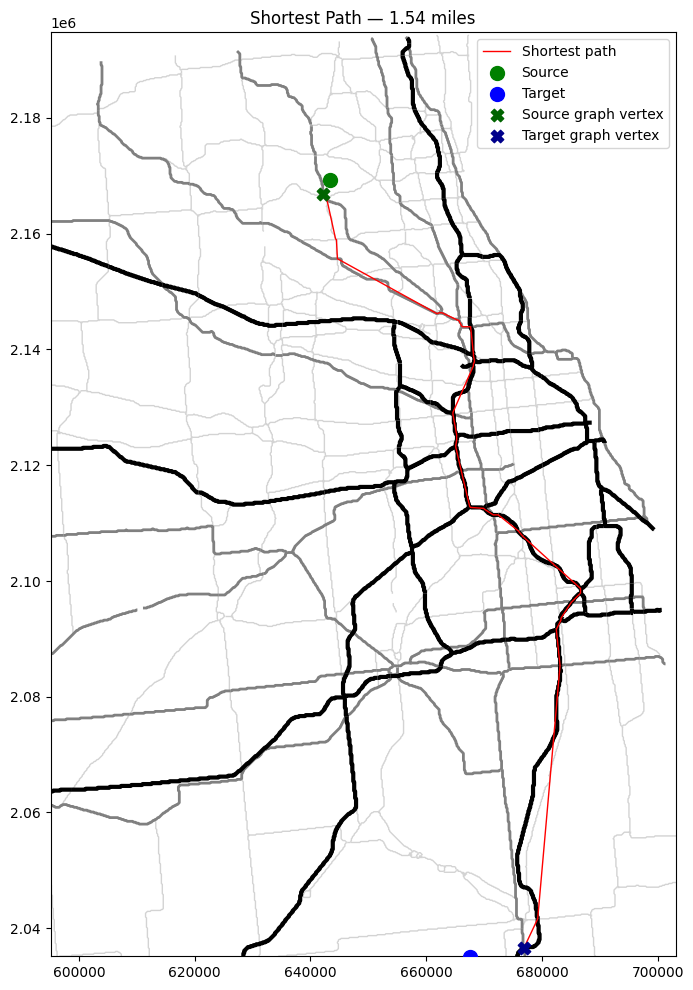

In [270]:
# Find closest graph node to source

weight = "travel_time_hours"


source_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'Wauconda')
)].iloc[0]


target_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'Kankakee')
)].iloc[0]

source_node = get_closest_vertex(source_point.geometry.representative_point(), G)
target_node = get_closest_vertex(target_point.geometry.representative_point(), G)

# Run shortest path using edge mileage
route_nodes = nx.shortest_path(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
)

route_miles = nx.shortest_path_length(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
    )


import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# Convert the ordered route nodes into a line
route_line = LineString(route_nodes)

# Plot
fig, ax = plt.subplots(
    figsize=(12, 12)
)

# Plot all atomic roads
atomic_interstate_us_roads_and_state_roads[
    (atomic_interstate_us_roads_and_state_roads['origin'] == 'I')
].plot(
    ax=ax,
    color="black",
    linewidth=3,
     zorder=3
)

atomic_interstate_us_roads_and_state_roads[
    (atomic_interstate_us_roads_and_state_roads['origin'] == 'U')
].plot(
    ax=ax,
    color="grey",
    linewidth=2,
    zorder=2
)

atomic_interstate_us_roads_and_state_roads[
    (atomic_interstate_us_roads_and_state_roads['origin'] == 'S')
].plot(
    ax=ax,
    color="lightgrey",
    linewidth=1,
    zorder=1
)


# Plot the shortest path
ax.plot(
    *route_line.xy,
    color="red",
    linewidth=1,
    label="Shortest path",
     zorder=4
)

# Plot the original source and target representative points
ax.scatter(
    source_point.geometry.representative_point().x,
    source_point.geometry.representative_point().y,
    color="green",
    s=100,
    marker="o",
    label="Source",
    zorder=5,
)

ax.scatter(
    target_point.geometry.representative_point().x,
    target_point.geometry.representative_point().y,
    color="blue",
    s=100,
    marker="o",
    label="Target",
    zorder=5,
)

# Plot the graph vertices used for routing
ax.scatter(
    source_node[0],
    source_node[1],
    color="darkgreen",
    s=80,
    marker="X",
    label="Source graph vertex",
    zorder=6,
)

ax.scatter(
    target_node[0],
    target_node[1],
    color="darkblue",
    s=80,
    marker="X",
    label="Target graph vertex",
    zorder=6,
)

ax.legend()

ax.set_title(
    f"Shortest Path — {route_miles:.2f} miles"
)

ZoomToTheExtentOf(ax, ILCollarCountiesArea)

plt.show()

In [276]:
import geopandas as gpd
from shapely.geometry import Point

graph_points = gpd.GeoDataFrame(
    {
        "node_id": list(G.nodes)
    },
    geometry=[
        Point(node)
        for node in G.nodes
    ],
    crs=TARGET_CRS
)

In [309]:
import networkx as nx

destination_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'LOOP')
)].iloc[0]['geometry']

# destination_point is a Shapely Point
destination_node = get_closest_vertex(
    destination_point,
    G
)

# Calculate shortest travel time from every node
travel_times = nx.single_source_dijkstra_path_length(
    G,
    source=destination_node,
    weight="travel_time_hours"
)

In [310]:
import geopandas as gpd
from shapely.geometry import Point

graph_points = gpd.GeoDataFrame(
    [
        {
            "node_id": node,
            "travel_time_hours": travel_time,
            "geometry": Point(node)
        }
        for node, travel_time in travel_times.items()
    ],
    crs=TARGET_CRS
)

C:\Users\Wayne\AppData\Local\Temp\ipykernel_47752\417366500.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


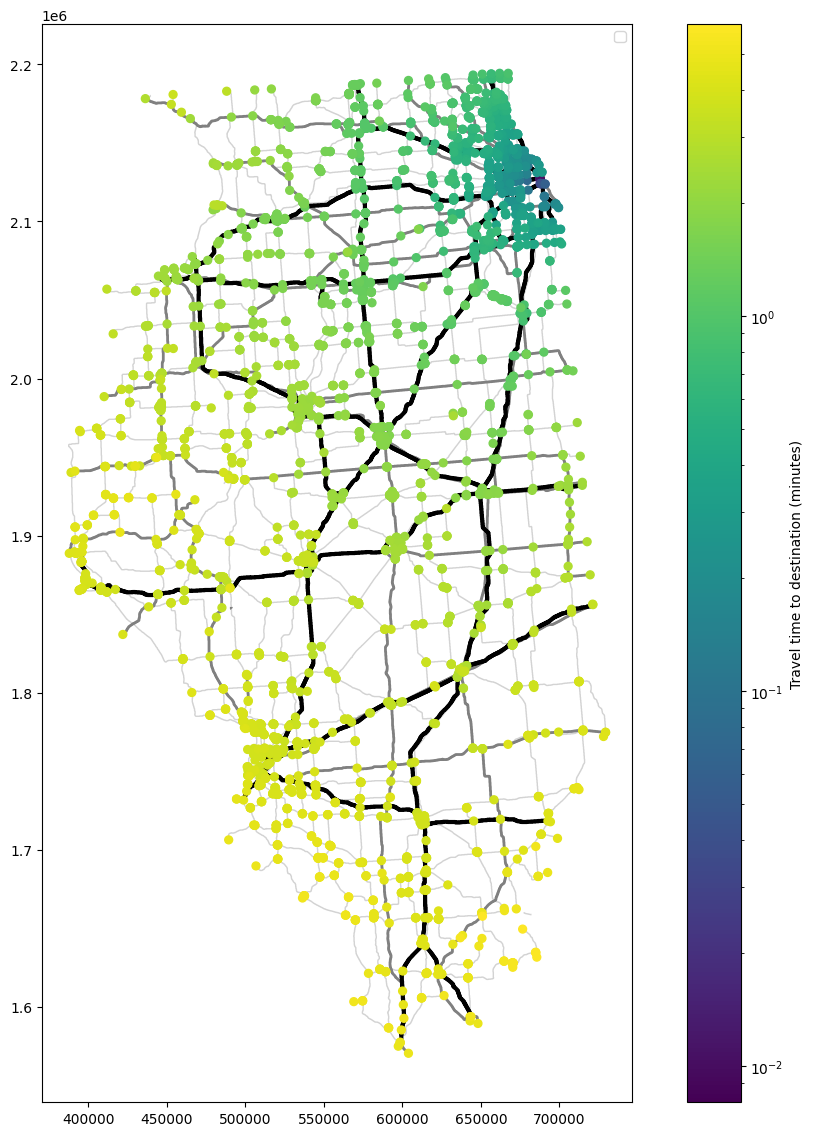

In [311]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(
    figsize=(14, 14)
)

# Plot all atomic roads
atomic_interstate_us_roads_and_state_roads[
    (atomic_interstate_us_roads_and_state_roads['origin'] == 'I')
].plot(
    ax=ax,
    color="black",
    linewidth=3,
     zorder=3
)

atomic_interstate_us_roads_and_state_roads[
    (atomic_interstate_us_roads_and_state_roads['origin'] == 'U')
].plot(
    ax=ax,
    color="grey",
    linewidth=2,
    zorder=2
)

atomic_interstate_us_roads_and_state_roads[
    (atomic_interstate_us_roads_and_state_roads['origin'] == 'S')
].plot(
    ax=ax,
    color="lightgrey",
    linewidth=1,
    zorder=1
)

# Remove zero values because log(0) is undefined
plot_points = graph_points[
    graph_points["travel_time_hours"] > 0
].copy()

plot_points.plot(
    ax=ax,
    column="travel_time_hours",
    cmap="viridis",
    markersize=32,
    norm=LogNorm(
        vmin=plot_points["travel_time_hours"].min(),
        vmax=plot_points["travel_time_hours"].max()
    ),
    legend=True,
    legend_kwds={
        "label": "Travel time to destination (minutes)"
    },
    zorder=100
)

ax.legend()

# ZoomToTheExtentOf(ax, ChicagoArea)

plt.show()

#### Hex Grid

In [350]:
import math
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon


def make_hexagon(center_x, center_y, radius):
    """
    Create a flat-top regular hexagon.

    radius is the distance from the center
    to each hexagon vertex.
    """

    angles = np.arange(0, 360, 60)

    coordinates = [
        (
            center_x + radius * np.cos(np.radians(angle)),
            center_y + radius * np.sin(np.radians(angle)),
        )
        for angle in angles
    ]

    return Polygon(coordinates)


def create_locked_place_hexagons(
    places_gdf,
    hex_radius=25_000,
    point_geometry="geometry",
):
    """
    Assign each place to a unique cell in a
    geographically positioned, edge-connected
    flat-top hexagonal lattice.

    Parameters
    ----------
    places_gdf : GeoDataFrame
        GeoDataFrame containing place Point geometries.

    hex_radius : float
        Center-to-vertex hexagon radius.

        For EPSG:5070:
        10,000 = 10 km
        25,000 = 25 km
        50,000 = 50 km

    point_geometry : str
        Name of the place point geometry column.

    Returns
    -------
    GeoDataFrame
        One locked hexagon for every place.
    """

    places = places_gdf.copy()
    places = places.set_geometry(point_geometry)

    if places.crs is None:
        raise ValueError(
            "places_gdf must have a projected CRS."
        )

    if not places.geometry.geom_type.isin(
        ["Point"]
    ).all():
        raise ValueError(
            "The active geometry must contain Points."
        )

    # -------------------------------------------------
    # Flat-top hexagonal grid spacing
    # -------------------------------------------------

    # Horizontal center-to-center spacing
    x_spacing = 1.5 * hex_radius

    # Vertical center-to-center spacing
    y_spacing = math.sqrt(3) * hex_radius

    # Grid extent
    min_x, min_y, max_x, max_y = (
        places.total_bounds
    )

    # Add enough padding to create many more
    # hexagons than there are places.
    #
    # Large hexagons require more padding because
    # fewer cells fit inside the original extent.
    padding = max(
        5 * hex_radius,
        np.sqrt(len(places)) * hex_radius,
    )

    min_x -= padding
    min_y -= padding
    max_x += padding
    max_y += padding

    # -------------------------------------------------
    # Generate a shared hexagonal lattice
    # -------------------------------------------------

    hex_cells = []

    column = 0
    x = min_x

    while x <= max_x:

        # Every other column is vertically offset
        y_offset = (
            y_spacing / 2
            if column % 2
            else 0
        )

        y = min_y + y_offset

        while y <= max_y:

            hex_cells.append(
                {
                    "hex_id": len(hex_cells),
                    "hex_column": column,
                    "hex_geometry": make_hexagon(
                        x,
                        y,
                        hex_radius,
                    ),
                }
            )

            y += y_spacing

        x += x_spacing
        column += 1

    hex_grid = gpd.GeoDataFrame(
        hex_cells,
        geometry="hex_geometry",
        crs=places.crs,
    )

    # -------------------------------------------------
    # Assign every place to a unique hexagon
    # -------------------------------------------------

    available_hex_ids = set(
        hex_grid["hex_id"]
    )

    assigned_rows = []

    for place_index, place_row in places.iterrows():

        point = place_row.geometry

        available_hexes = hex_grid[
            hex_grid["hex_id"].isin(
                available_hex_ids
            )
        ].copy()

        # Distance from place to hex center
        available_hexes["distance"] = (
            available_hexes.geometry.centroid.distance(
                point
            )
        )

        # Closest unused grid cell
        closest_hex = (
            available_hexes
            .sort_values("distance")
            .iloc[0]
        )

        available_hex_ids.remove(
            closest_hex["hex_id"]
        )

        output_row = place_row.copy()

        # Keep the original geographic point
        output_row["place_point"] = point

        # Add hex-grid information
        output_row["hex_id"] = (
            closest_hex["hex_id"]
        )

        output_row["hex_column"] = (
            closest_hex["hex_column"]
        )

        # Center of the assigned hexagon
        output_row["hex_center"] = (
            closest_hex["hex_geometry"].centroid
        )

        # Use the assigned hexagon as the output geometry
        output_row["geometry"] = (
            closest_hex["hex_geometry"]
        )

        assigned_rows.append(
            output_row
        )

    place_hexagons = gpd.GeoDataFrame(
        assigned_rows,
        geometry="geometry",
        crs=places.crs,
    )

    return place_hexagons

In [329]:
ILPlaces2022WithChicagoCommunity_AndCensus['representative_point'] = ILPlaces2022WithChicagoCommunity_AndCensus['geometry'].representative_point()

In [332]:
ILPlaces2022WithChicagoCommunity_AndCensus = ILPlaces2022WithChicagoCommunity_AndCensus.set_geometry('representative_point')

In [353]:
place_hexagons = create_locked_place_hexagons(
    places_gdf=ILPlaces2022WithChicagoCommunity_AndCensus,
    hex_radius=5_000,
    point_geometry='representative_point'
)

In [354]:
from shapely.geometry import Polygon
import numpy as np
import geopandas as gpd


def make_hexagon(x, y, radius):
    """
    Create a flat-top regular hexagon.
    """

    angles = np.arange(0, 360, 60)

    coordinates = [
        (
            x + radius * np.cos(
                np.radians(angle)
            ),
            y + radius * np.sin(
                np.radians(angle)
            ),
        )
        for angle in angles
    ]

    return Polygon(coordinates)


def create_state_shaped_hexagons(
    places_gdf,
    state_gdf,
    hex_radius=50_000,
    point_geometry="representative_point",
):
    """
    Create one locked hexagon per place.

    The hexagonal topology is constrained to
    roughly follow the state boundary.
    """

    # -----------------------------------------
    # Prepare place points
    # -----------------------------------------

    places = places_gdf.copy()

    places = places.set_geometry(
        point_geometry
    )

    from shapely.geometry.base import BaseGeometry


    # -----------------------------------------
    # Prepare state boundary
    # -----------------------------------------

    # Accept:
    # 1. GeoDataFrame
    # 2. GeoSeries
    # 3. A single Shapely Polygon/MultiPolygon
    if isinstance(state_gdf, BaseGeometry):

        state_geometry = state_gdf

    elif isinstance(state_gdf, gpd.GeoDataFrame):

        state = state_gdf.copy()

        if state.crs != places.crs:
            state = state.to_crs(
                places.crs
            )

        state_geometry = (
            state.geometry.union_all()
        )

    elif isinstance(state_gdf, gpd.GeoSeries):

        state = state_gdf.copy()

        if state.crs != places.crs:
            state = state.to_crs(
                places.crs
            )

        state_geometry = (
            state.union_all()
        )

    else:

        raise TypeError(
            "state_gdf must be a GeoDataFrame, "
            "GeoSeries, or a Shapely geometry."
        )

    # -----------------------------------------
    # Hex-grid dimensions
    # -----------------------------------------

    # Flat-top hexagons
    x_spacing = (
        1.5 * hex_radius
    )

    y_spacing = (
        np.sqrt(3) * hex_radius
    )

    # State extent
    min_x, min_y, max_x, max_y = (
        state_geometry.bounds
    )

    # Add one hexagon around the boundary
    min_x -= hex_radius
    min_y -= hex_radius
    max_x += hex_radius
    max_y += hex_radius

    # -----------------------------------------
    # Create the complete hex lattice
    # -----------------------------------------

    hex_rows = []

    column = 0
    x = min_x

    while x <= max_x:

        # Offset every other column
        y_offset = (
            y_spacing / 2
            if column % 2
            else 0
        )

        y = min_y + y_offset

        while y <= max_y:

            hexagon = make_hexagon(
                x,
                y,
                hex_radius,
            )

            # Keep only cells that intersect
            # the Illinois boundary
            if hexagon.intersects(
                state_geometry
            ):

                hex_rows.append(
                    {
                        "hex_id": len(
                            hex_rows
                        ),
                        "hex_column": column,
                        "hex_geometry": hexagon,
                    }
                )

            y += y_spacing

        x += x_spacing
        column += 1

    # -----------------------------------------
    # Create the state-shaped hex grid
    # -----------------------------------------

    hex_grid = gpd.GeoDataFrame(
        hex_rows,
        geometry="hex_geometry",
        crs=places.crs,
    )

    print(
        f"Places: {len(places):,}"
    )

    print(
        f"State hexagons: "
        f"{len(hex_grid):,}"
    )

    # -----------------------------------------
    # Ensure enough hexagons exist
    # -----------------------------------------

    if len(hex_grid) < len(places):

        raise ValueError(
            f"Only {len(hex_grid):,} "
            f"state hexagons were generated "
            f"for {len(places):,} places. "
            f"Decrease hex_radius."
        )

    # -----------------------------------------
    # Assign each place to a unique hexagon
    # -----------------------------------------

    available_hex_ids = set(
        hex_grid["hex_id"]
    )

    output_rows = []

    for place_index, place_row in (
        places.iterrows()
    ):

        point = place_row.geometry

        available_hexes = (
            hex_grid[
                hex_grid["hex_id"].isin(
                    available_hex_ids
                )
            ]
            .copy()
        )

        if available_hexes.empty:

            raise RuntimeError(
                "No unused state hexagons "
                "remain."
            )

        # Distance from each hex center
        available_hexes[
            "distance"
        ] = (
            available_hexes
            .geometry
            .centroid
            .distance(point)
        )

        # Select the closest unused cell
        closest_hex = (
            available_hexes
            .sort_values(
                "distance"
            )
            .iloc[0]
        )

        # Mark the cell as occupied
        available_hex_ids.remove(
            closest_hex["hex_id"]
        )

        # Copy place attributes
        output_row = (
            place_row.copy()
        )

        # Preserve original place point
        output_row[
            "place_point"
        ] = point

        # Store topology information
        output_row[
            "hex_id"
        ] = closest_hex[
            "hex_id"
        ]

        output_row[
            "hex_column"
        ] = closest_hex[
            "hex_column"
        ]

        # Get polygon from the Series
        hex_polygon = (
            closest_hex[
                "hex_geometry"
            ]
        )

        output_row[
            "hex_center"
        ] = (
            hex_polygon.centroid
        )

        # Make the hexagon active geometry
        output_row[
            "geometry"
        ] = hex_polygon

        output_rows.append(
            output_row
        )

    # -----------------------------------------
    # Final GeoDataFrame
    # -----------------------------------------

    place_hexagons = gpd.GeoDataFrame(
        output_rows,
        geometry="geometry",
        crs=places.crs,
    )

    return place_hexagons

In [414]:
place_hexagons = create_state_shaped_hexagons(
    places_gdf=ILPlaces2022WithChicagoCommunity_AndCensus,
    state_gdf=ILCounties.geometry.union_all(),
    hex_radius=8_000,
    point_geometry="representative_point",
)

Places: 897
State hexagons: 964


C:\Users\Wayne\AppData\Local\Temp\ipykernel_47752\3620089957.py:3: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  places_within_areas = gpd.sjoin(


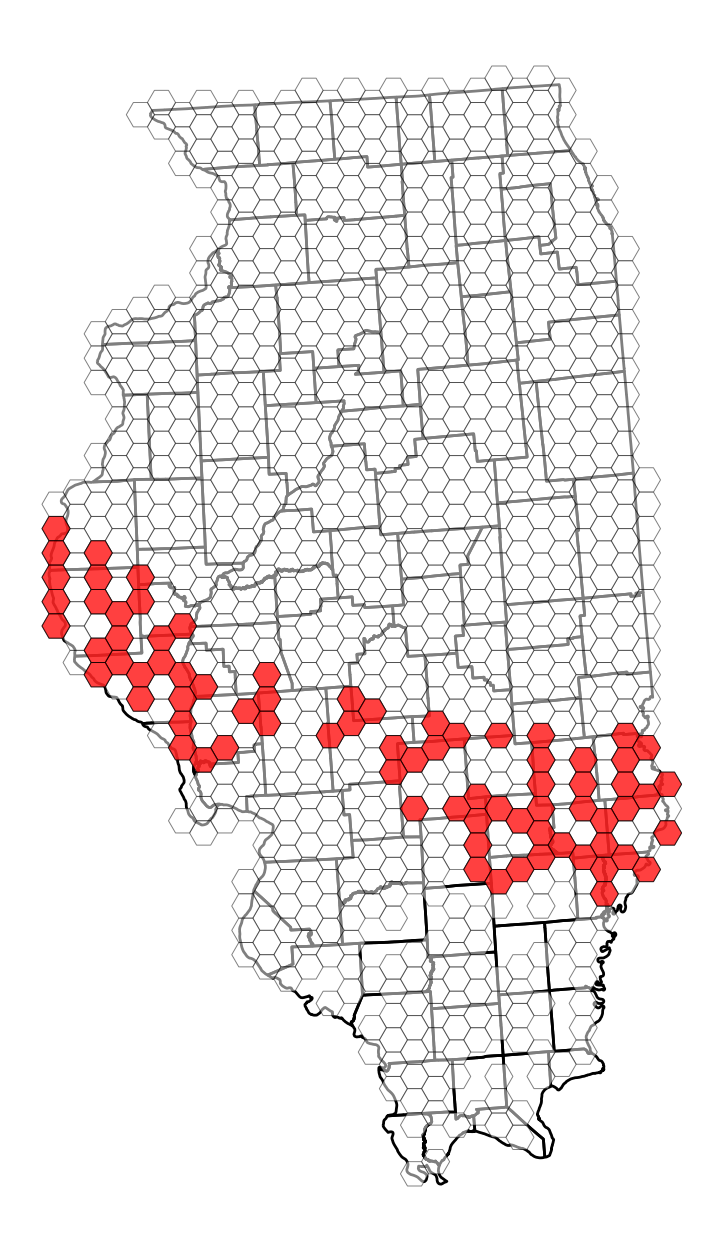

In [415]:
import matplotlib.pyplot as plt

places_within_areas = gpd.sjoin(
    place_hexagons.set_geometry(
        "representative_point"
    ),
    ChicagoArea,
    how="inner",
    predicate="within",
)

fig, ax = plt.subplots(
    figsize=(12, 16)
)

# State boundary
ILCounties.to_crs(
    place_hexagons.crs
).boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
)

# Assigned place hexagons
place_hexagons.plot(
    ax=ax,
    facecolor="#ffffff",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.5,
    zorder=2
)

places_within_areas.set_geometry('geometry').plot(
    ax=ax,
    facecolor="red",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.75,
    zorder=3
)


ax.set_aspect("equal")

ax.set_axis_off()

plt.show()

In [416]:
from scipy.optimize import linear_sum_assignment
import numpy as np


# -----------------------------------------
# Global place-to-hex assignment
# -----------------------------------------

places = ILPlaces2022WithChicagoCommunity_AndCensus
hex_grid = place_hexagons

# Place coordinates
place_x = places.geometry.x.to_numpy()
place_y = places.geometry.y.to_numpy()

# Hexagon-center coordinates
hex_centers = hex_grid.geometry.centroid

hex_x = hex_centers.x.to_numpy()
hex_y = hex_centers.y.to_numpy()

# -----------------------------------------
# Build the distance cost matrix
# -----------------------------------------

# Shape:
#     rows    = places
#     columns = available hexagons
distance_matrix = np.sqrt(
    (place_x[:, None] - hex_x[None, :]) ** 2
    +
    (place_y[:, None] - hex_y[None, :]) ** 2
)

# -----------------------------------------
# Find the globally optimal assignment
# -----------------------------------------

place_indices, hex_indices = (
    linear_sum_assignment(
        distance_matrix
    )
)

# -----------------------------------------
# Build the output GeoDataFrame
# -----------------------------------------

output_rows = []

for place_position, hex_position in zip(
    place_indices,
    hex_indices,
):

    # Original place row
    place_row = (
        places
        .iloc[place_position]
        .copy()
    )

    # Assigned hexagon row
    hex_row = (
        hex_grid
        .iloc[hex_position]
    )

    # Assigned hexagon polygon
    hex_polygon = (
        hex_row["geometry"]
    )

    # Preserve original place point
    place_row[
        "place_point"
    ] = (
        place_row.geometry
    )

    # Hexagon information
    place_row[
        "hex_id"
    ] = (
        hex_row["hex_id"]
    )

    place_row[
        "hex_column"
    ] = (
        hex_row["hex_column"]
    )

    place_row[
        "hex_center"
    ] = (
        hex_polygon.centroid
    )

    # Distance from place to assigned hex center
    place_row[
        "hex_distance"
    ] = (
        distance_matrix[
            place_position,
            hex_position
        ]
    )

    # Make the hexagon the active geometry
    place_row[
        "geometry"
    ] = (
        hex_polygon
    )

    output_rows.append(
        place_row
    )

# Final result
place_hexagons_rearranged = gpd.GeoDataFrame(
    output_rows,
    geometry="geometry",
    crs=places.crs,
)

In [418]:
# Census Codes

census_codes = {
    "GEO_ID": "GEOID",
    "B02001_001E": "Race",
    "B03002_003E": "White alone, non-Hispanic",
    "B03002_004E": "Black alone, non-Hispanic",
    "B03002_012E": "Hispanic or Latino",
    "B03002_005E": "American Indian and Alaska Native Alone, non-Hispanic",
    "B03002_006E": "Asian Alone, non-Hispanic",
    "B03002_007E": "Native Hawaiian and Other Pacific Islander Alone, non-Hispanic",
    "B15003_020E": "Some college, 1 or more years, no degree", # not in ACS 2010
    "B15003_021E": "Associate's degree",
    "B15003_022E": "Bachelor's degree",
    "B15003_023E": "Master's degree",
    "B15003_024E": "Professional school degree",
    "B15003_025E": "Doctorate degree",
    "B19013_001E": "Median Household Income",
    "B17001_002E": "Income in the past 12 months below poverty level",
    "B25064_001E": "Median Gross Rent",
    "B05001_002E": "Native, Total Population",
    "B05001_004E": "Foreign born, Naturalized U.S. Citizen",
    "B25034_001E": "Total Structures",
    "B25034_002E": "Built 2020s",
    "B25034_003E": "Built 2010s",
    "B25034_004E": "Built 2000s",
    "B25034_005E": "Built 1990s",
    "B25034_006E": "Built 1980s",
    "B25034_007E": "Built 1970s",
    "B25034_008E": "Built 1960s",
    "B25034_009E": "Built 1950s",
    "B25034_010E": "Built 1940s",
    "B25034_011E": "Built Before 1940",
    "B27001_002E": "Male, Health insurance Coverage",
    "B27001_018E": "Female, Health insurance Coverage",
    "B25003_001E": "Occupied Housing Units",
    "B25003_003E": "Renter occupied",
    "B25003_002E": "Owner occupied",
    "B08303_002E": "Travel Time, less than 5 minutes",
    "B08303_003E": "Travel Time, 5-9 minutes",
    "B08303_004E": "Travel Time, 10-14 minutes",
    "B08303_005E": "Travel Time, 15-19 minutes",
    "B08303_006E": "Travel Time, 20-24 minutes",
    "B08303_007E": "Travel Time, 25-29 minutes",
    "B08303_008E": "Travel Time, 30-34 minutes",
    "B08303_009E": "Travel Time, 35-39 minutes",
    "B08303_010E": "Travel Time, 40-44 minutes",
    "B08303_011E": "Travel Time, 45-59 minutes",
    "B08303_012E": "Travel Time, 60-89 minutes",
    "B08303_013E": "Travel Time, 90 minutes or more",
    "B08301_003E": "Car, truck, or van, Drove Alone",
    "B08301_004E": "Car, truck, or van, Carpool",
    "B08301_011E": "Public transportation, Bus",
    "B08301_012E": "Public transportation, Light Rail",
    "B08301_013E": "Public transportation, Hard Rail",
    "B23025_002E": "Labor force",
    "B23025_005E": "Unemployed persons",
    "B23025_007E": "Not in labor force",
    "B16001_001E": "Language at home, Total",
    "B16001_002E": "Language at home, only English",
    "B16001_003E": "Language at home, Spanish",
    "B21001_002E": "Veteran",
    "B11005_001E": "Households",
    "B11005_002E": "Households with one or more people under 18 years",
    "B01001_003E": "Male, Under 5",
    "B01001_004E": "Male, 5 to 9 years",
    "B01001_005E": "Male, 10 to 14 years",
    "B01001_006E": "Male, 15 to 17 years",
    "B01001_007E": "Male, 18 to 19 years",
    "B01001_008E": "Male, 20 years",
    "B01001_009E": "Male, 21 years",
    "B01001_010E": "Male, 22 to 24 years",
    "B01001_011E": "Male, 25 to 29 years",
    "B01001_012E": "Male, 30 to 34 years",
    "B01001_013E": "Male, 35 to 39 years",
    "B01001_014E": "Male, 40 to 44 years",
    "B01001_015E": "Male, 45 to 49 years",
    "B01001_016E": "Male, 50 to 54 years",
    "B01001_017E": "Male, 55 to 59 years",
    "B01001_018E": "Male, 60 and 61 years",
    "B01001_019E": "Male, 62 to 64 years",
    "B01001_020E": "Male, 65 and 66 years",
    "B01001_021E": "Male, 67 to 69 years",
    "B01001_022E": "Male, 70 to 74 years",
    "B01001_023E": "Male, 75 to 79 years",
    "B01001_024E": "Male, 80 to 84 years",
    "B01001_025E": "Male, 85 years and over",
    "B01001_027E": "Female, Under 5",
    "B01001_028E": "Female, 5 to 9 years",
    "B01001_029E": "Female, 10 to 14 years",
    "B01001_030E": "Female, 15 to 17 years",
    "B01001_031E": "Female, 18 to 19 years",
    "B01001_032E": "Female, 20 years",
    "B01001_033E": "Female, 21 years",
    "B01001_034E": "Female, 22 to 24 years",
    "B01001_035E": "Female, 25 to 29 years",
    "B01001_036E": "Female, 30 to 34 years",
    "B01001_037E": "Female, 35 to 39 years",
    "B01001_038E": "Female, 40 to 44 years",
    "B01001_039E": "Female, 45 to 49 years",
    "B01001_040E": "Female, 50 to 54 years",
    "B01001_041E": "Female, 55 to 59 years",
    "B01001_042E": "Female, 60 and 61 years",
    "B01001_043E": "Female, 62 to 64 years",
    "B01001_044E": "Female, 65 and 66 years",
    "B01001_045E": "Female, 67 to 69 years",
    "B01001_046E": "Female, 70 to 74 years",
    "B01001_047E": "Female, 75 to 79 years",
    "B01001_048E": "Female, 80 to 84 years",
    "B01001_049E": "Female, 85 years and over",
}

CODES = {
    value: key
    for key, value in census_codes.items()
}


C:\Users\Wayne\AppData\Local\Temp\ipykernel_47752\3520429383.py:3: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  places_within_chicago = gpd.sjoin(
C:\Users\Wayne\AppData\Local\Temp\ipykernel_47752\3520429383.py:12: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  places_within_collar = gpd.sjoin(


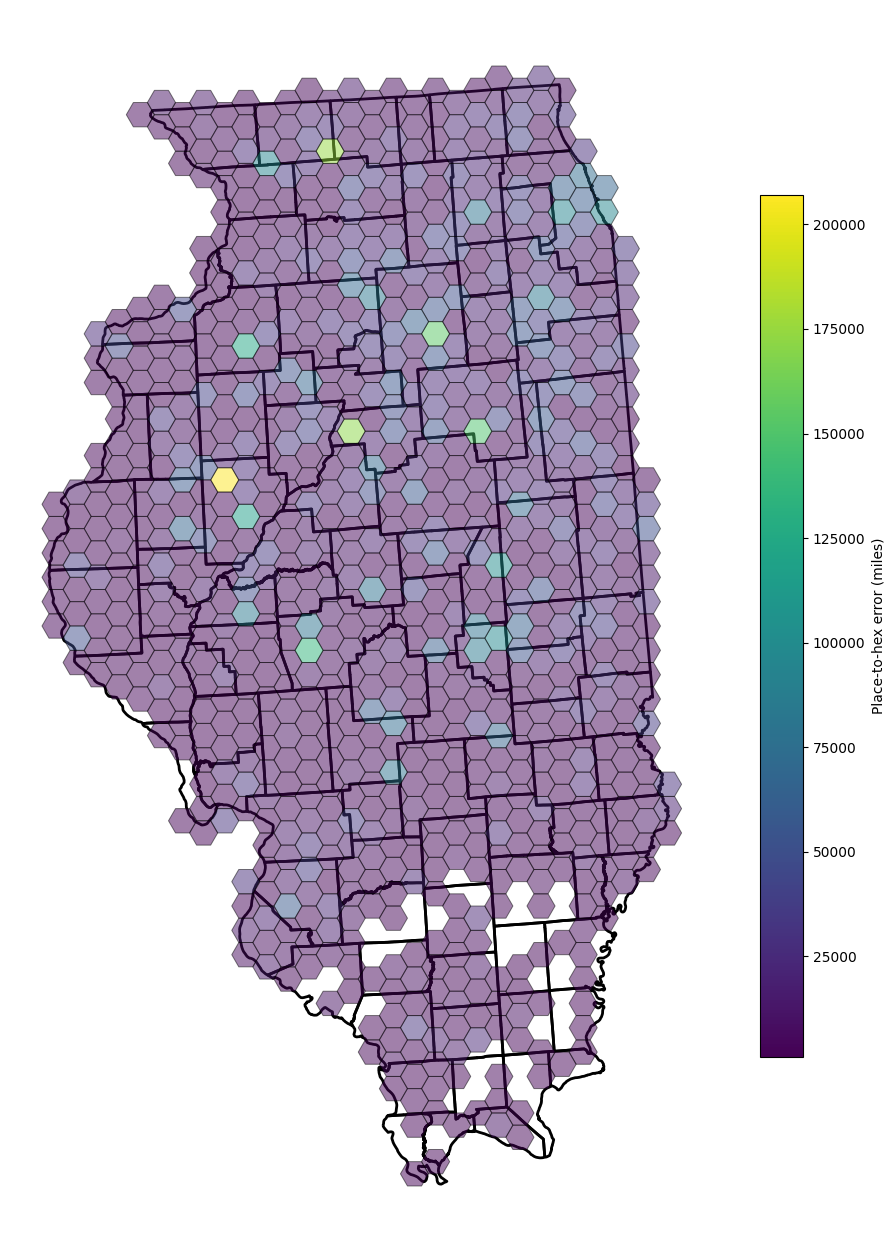

In [437]:
import matplotlib.pyplot as plt

places_within_chicago = gpd.sjoin(
    place_hexagons_rearranged.set_geometry(
        "representative_point"
    ),
    ChicagoArea,
    how="inner",
    predicate="within",
)

places_within_collar = gpd.sjoin(
    place_hexagons_rearranged.set_geometry(
        "representative_point"
    ),
    ILCollarCountiesArea,
    how="inner",
    predicate="within",
)

fig, ax = plt.subplots(
    figsize=(12, 16)
)

# State boundary
ILCounties.to_crs(
    place_hexagons.crs
).boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
)

# Assigned place hexagons
place_hexagons_rearranged.plot(
    ax=ax,
    column=CODES['Race'],
    facecolor="#ffffff",
    edgecolor="black",
    linewidth=0.7,
    # vmin==10**1,
    # vmax=10**7,
    # norm=LogNorm(
    #     vmin=10**1,
    #     vmax=10**7,
    # ),
    alpha=0.5,
    zorder=2,
    legend=True,
    legend_kwds={
        "label": (
            "Place-to-hex error "
            "(miles)"
        ),
        "shrink": 0.7,
    },
)


# places_within_collar.set_geometry('geometry').plot(
#     ax=ax,
#     facecolor="orange",
#     edgecolor="black",
#     linewidth=0.7,
#     alpha=0.75,
#     zorder=3
# )


# places_within_chicago.set_geometry('geometry').plot(
#     ax=ax,
#     facecolor="red",
#     edgecolor="black",
#     linewidth=0.7,
#     alpha=0.75,
#     zorder=3
# )



ax.set_aspect("equal")

ax.set_axis_off()

plt.show()

In [443]:
ILPlaces2022WithChicagoCommunity_AndCensus.sort_values(CODES['Race'], ascending=False)[20:30]

,PLACE_GEOID,PLACE_NAME,B02001_001E,B03002_003E,B03002_004E,B03002_012E,B03002_005E,B03002_006E,B03002_007E,B15003_020E,...,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,B19013_001E,B25064_001E,community,geometry,representative_point
64,1706613,Bloomington,77954,57236,7110,4814,230,6356,13,6838,...,907,1605,836,747,826,57375.0,790.0,NaN,"POLYGON ((594958.414 1955121.593, 594961.435 1...",POINT (589579.89 1960358.775)
884,NaN,SOUTH LAWNDALE,77334,4301,9308,63181,54,270,0,4864,...,976,969,575,352,421,37639.0,828.0,SOUTH LAWNDALE,"POLYGON ((683212.753 2121638.608, 683170.439 2...",POINT (682431.472 2122541.102)
229,1724582,Evanston,73979,43121,11806,8749,23,6796,0,4143,...,1287,1890,766,994,1323,84271.0,1409.0,NaN,"POLYGON ((680943.795 2143819.042, 680931.696 2...",POINT (682745.178 2145664.289)
860,NaN,LOGAN SQUARE,72305,37608,3233,26061,14,3048,7,4361,...,670,639,326,322,612,83000.0,1429.0,LOGAN SQUARE,"POLYGON ((680788.573 2131311.945, 680778.128 2...",POINT (682665.137 2132283.15)
858,NaN,LINCOLN PARK,69568,55637,2636,4349,11,5084,2,2454,...,576,776,483,336,358,141521.0,1806.5,LINCOLN PARK,"MULTIPOLYGON (((687035.827 2131154.384, 686975...",POINT (686701.581 2132402.563)
564,1757225,Palatine,68892,43565,2217,14718,18,6992,2,6101,...,925,1488,1102,568,855,79886.5,1320.0,NaN,"POLYGON ((648785.453 2150286.231, 648831.982 2...",POINT (653522.796 2151031.242)
877,NaN,PORTAGE PARK,68172,33135,1096,27922,106,4162,0,5643,...,810,1013,993,553,921,71250.0,1104.0,PORTAGE PARK,"MULTIPOLYGON (((674125.436 2135218.771, 674128...",POINT (677102.06 2135060.189)
186,1719642,Des Plaines,67551,40637,2556,12429,232,10223,33,6276,...,1166,1257,1517,981,1480,72887.0,1122.5,NaN,"POLYGON ((666771.894 2139308.565, 666725.099 2...",POINT (666042.516 2142948.436)
880,NaN,ROGERS PARK,67481,31040,17692,11908,30,3952,8,5690,...,731,852,432,585,520,44107.0,1075.0,ROGERS PARK,"MULTIPOLYGON (((684566.467 2140728.576, 684537...",POINT (684237.992 2142086.283)
823,NaN,ASHBURN,66047,15306,21978,26923,35,772,0,6848,...,698,999,853,592,749,72074.0,1287.0,ASHBURN,"MULTIPOLYGON (((681117.802 2111313.262, 681114...",POINT (683619.126 2112401.306)


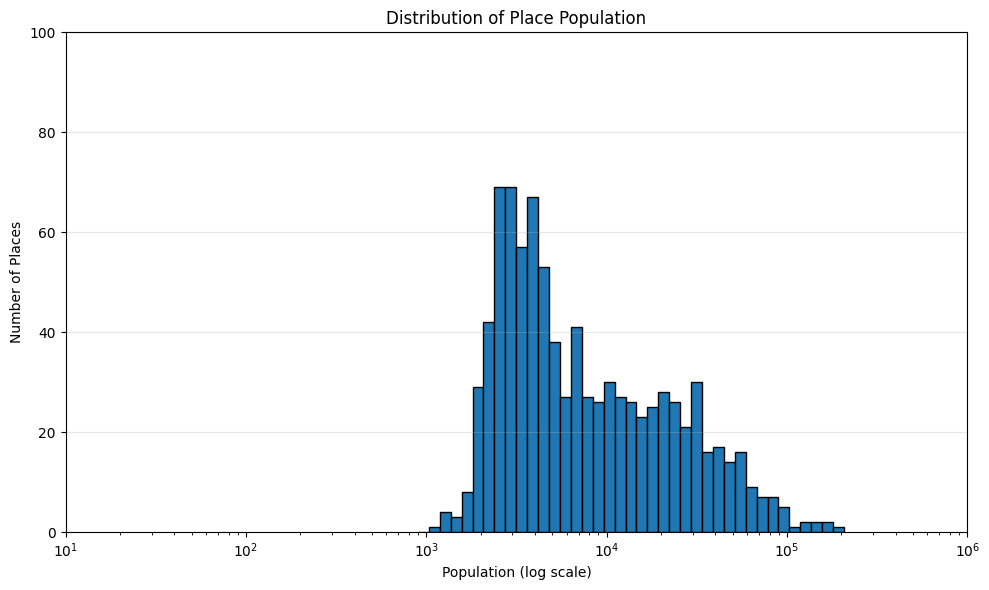

In [429]:
import numpy as np
import matplotlib.pyplot as plt

# Remove missing and non-positive populations
population = (
    ILPlaces2022WithChicagoCommunity_AndCensus[CODES['Race']]
    .dropna()
)

population = population[
    population > 0
]

# Create logarithmically spaced bins
bins = np.logspace(
    np.log10(population.min()),
    np.log10(population.max()),
    40,
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    population,
    bins=bins,
    edgecolor="black",
)

# Logarithmic population axis
ax.set_xscale("log")

# Optional: limit number of places shown
ax.set_ylim(
    0,
    100,
)

ax.set_title(
    "Distribution of Place Population"
)

ax.set_xlabel(
    "Population (log scale)"
)

ax.set_ylabel(
    "Number of Places"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.set_xlim(10**1, 10**6)

plt.tight_layout()
plt.show()

In [397]:
print(
    place_hexagons_rearranged[
        "hex_distance"
    ].describe()
)

count       897.000000
mean      21028.389027
std       25637.173989
min          77.695195
25%        4414.610505
50%        8964.466486
75%       28077.399658
max      125093.870323
Name: hex_distance, dtype: float64
